# Remote Inference with Ray Serve

**How to run checkmaite capabilities with models deployed on a Ray Serve cluster**

This notebook demonstrates how to use checkmaite's Ray Serve integration to run model inference remotely. The general steps are:

* Start a local Ray cluster
* Deploy models as Ray Serve deployments
* Create MAITE-compliant client wrappers that call the remote deployments
* Use the clients with checkmaite capabilities (MaiteEvaluation, NrtkRobustness) just like local models

The Ray Serve integration lives in `checkmaite.core.serving.rayserve` and provides:
* **Deployment classes** — wrap existing checkmaite models for serving via Ray
* **Client classes** — MAITE-compliant wrappers that call remote deployments via `DeploymentHandle`

**IMPORTANT**:
* **Since we are using mini test datasets, the values presented in the results may not have significant meaning.** Use full datasets with models trained on similar data to view accurate results.
* This notebook requires a dev install since it utilizes data from the test suite.

### Prerequisites

For multi-node clusters, start a Ray head node from your terminal before running this notebook:

```bash
ray start --head --num-cpus 4 --num-gpus 0
```

For GPU-enabled inference, adjust `--num-gpus`:

```bash
ray start --head --num-cpus 4 --num-gpus 1
```

Once the cluster is running, you can monitor deployments, logs, and resource usage via the **Ray Dashboard** at [http://127.0.0.1:8265](http://127.0.0.1:8265). The **Serve** tab shows active applications, deployment status, and replica health.

To stop a manually-started cluster when you're done:

```bash
ray stop
```

In [ ]:
import logging
import os
from pathlib import Path
import warnings

from ray import serve

from checkmaite import cache_path

logger = logging.getLogger(__name__)

BASE_DIR = Path.cwd().parents[1]
EXAMPLE_DATA_DIR = BASE_DIR / "tests/data_for_tests"
EXAMPLE_COCO_DATASET_DIR = EXAMPLE_DATA_DIR.joinpath('coco_resized_val2017').resolve()
EXAMPLE_YOLO_DATASET_DIR = EXAMPLE_DATA_DIR.joinpath('yolo_dataset').resolve()
EXAMPLE_VISDRONE_DATASET_DIR = EXAMPLE_DATA_DIR.joinpath('visdrone_dataset')

warnings.filterwarnings("ignore", category=UserWarning)

### Set cache path

In [ ]:
cache_path('tscache')
print(f'Cache path: {cache_path()}')

## Deploy a model to Ray Serve

Ray Serve has the concepts of applications and deployments. Applications are made up of multiple deployments and are like a namespace to manage the deployments.

We use `RayObjectDetectionDeployment` to create a Ray Serve deployment. Call `.options()` to configure the deployment (name, num_replicas, ray_actor_options, etc.), then `.bind()` to create the deployment graph, and finally `serve.run()` to deploy it.

We pass `route_prefix=None` to `serve.run()` because we use `DeploymentHandle` for in-cluster calls rather than HTTP. Without this, each application would default to the `/` HTTP route and conflict with each other when deploying multiple applications.

We also pass the name of the application to `serve.run()` using the name kwarg.

In [ ]:
from checkmaite.core.object_detection.models import VisdroneODModel
from checkmaite.core.serving.rayserve import RayObjectDetectionDeployment, RayObjectDetectionClient

# create the base checkmaite model object
checkmaite_model_wrapper = VisdroneODModel, {"arch": "resnet18"}

# create the ray deployment wrapper
visdrone_od_app = RayObjectDetectionDeployment.options(
    name="VisdroneODModel-v1",
).bind(*checkmaite_model_wrapper)

# deploy the model onto the ray cluster
visdrone_od_handle = serve.run(visdrone_od_app, name="checkmaite", route_prefix=None)

# create MAITE-compliant client from the deployment handle
visdrone_od_client = RayObjectDetectionClient(visdrone_od_handle)
print(f"Deployed: {visdrone_od_client.name}")
print(visdrone_od_client.metadata["model_cls"])

## Model discovery

Users can discover what models/applications are deployed in Ray Serve using the following methods:

1. **Ray Dashboard** (Web UI): Visit http://localhost:8265 to browse all applications and their deployment statuses

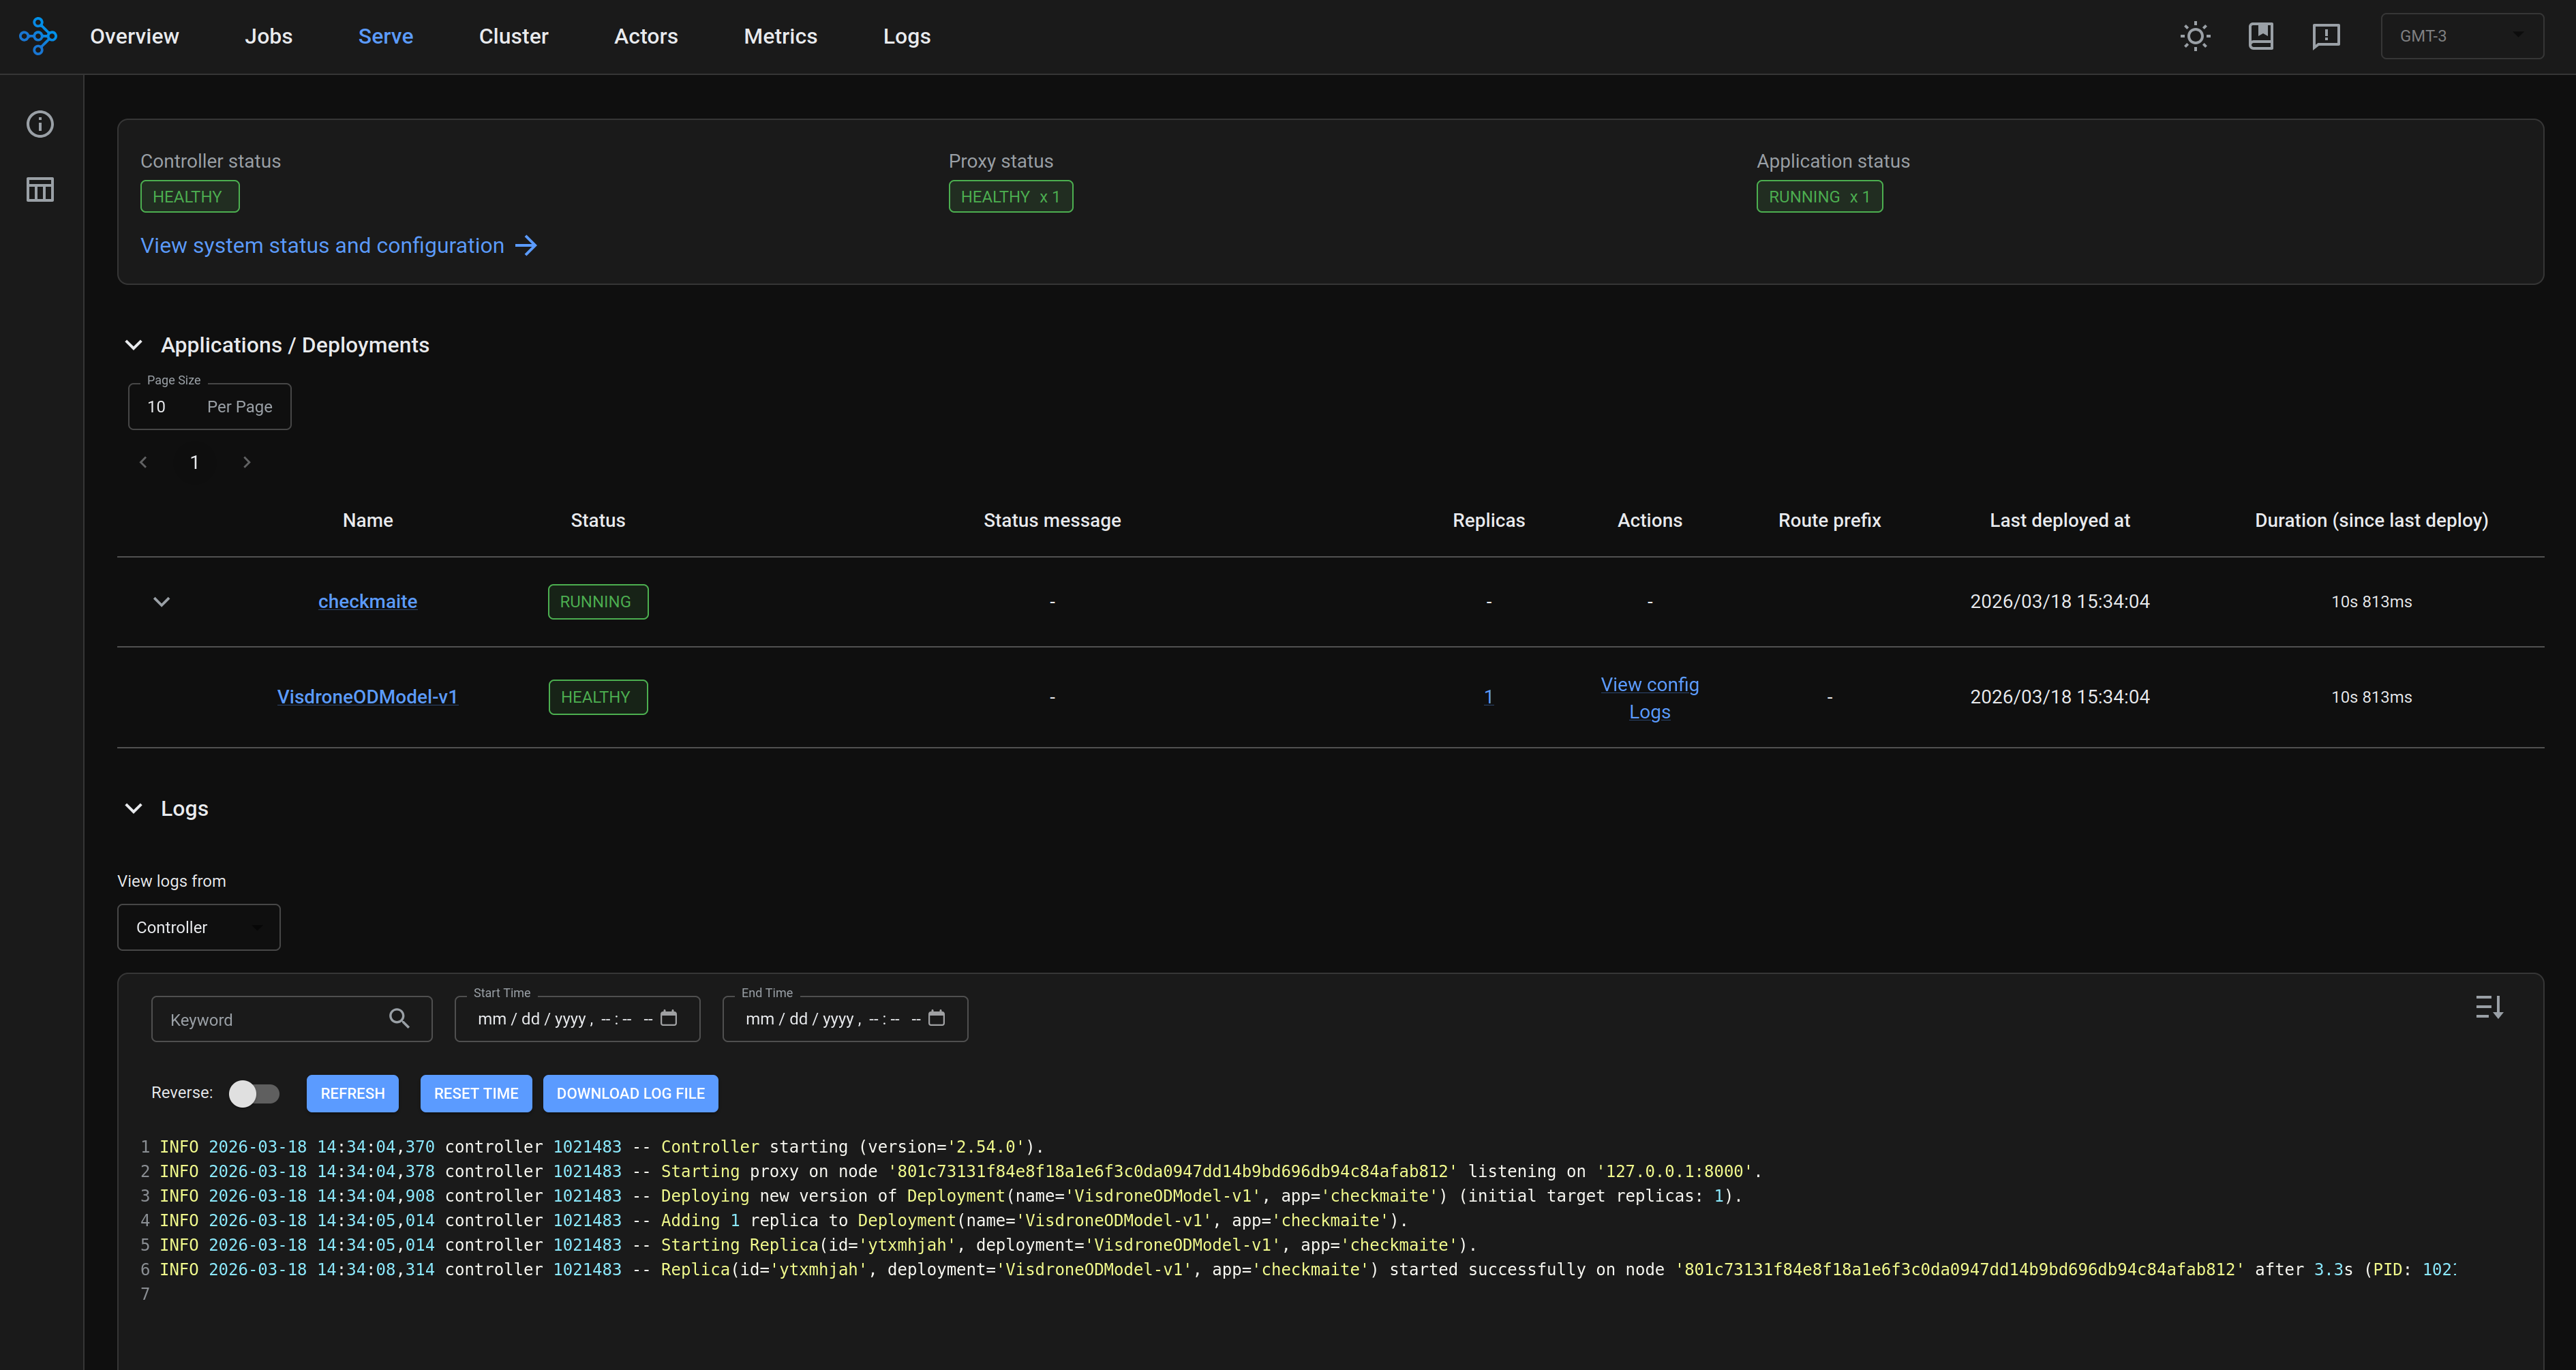

2. **Programmatically**: Use serve.status() to query the cluster

A helper method is implemented to show what applications and deployments are available.

In [ ]:
from checkmaite.core.serving.rayserve import print_serve_status
print_serve_status()

#### Reconnect to an already-deployed model

If a model has already been deployed (e.g., by another process or a previous notebook run), you don't need to call `serve.run()` again. Use `serve.get_deployment_handle()` to get a handle to an existing deployment by specifying the **deployment name** (set via `.options(name=...)`) and the **application name** (set via `serve.run(..., name=...)`), as shown in the helper method `print_serve_status()` above.



In [ ]:
# Reconnect to the VisDrone OD model that was deployed above
visdrone_od_handle_reconnected = serve.get_deployment_handle(
    deployment_name="VisdroneODModel-v1",
    app_name="checkmaite",
)

# Create a client from the reconnected handle — works identically
visdrone_od_client_reconnected = RayObjectDetectionClient(visdrone_od_handle_reconnected)
print(f"Reconnected to: {visdrone_od_client_reconnected.name}")
print(visdrone_od_client_reconnected.metadata["model_cls"])

## Load dataset

Load the same dataset wrappers used in local workflows. The Ray Serve clients are drop-in replacements for local models, so datasets and metrics remain unchanged.

In [ ]:
from checkmaite.core.object_detection.dataset_loaders import VisdroneDetectionDataset

visdrone_dataset = VisdroneDetectionDataset(root=str(EXAMPLE_VISDRONE_DATASET_DIR))
print(f"VisDrone dataset: {len(visdrone_dataset)} images")

### Create metric wrapper

In [ ]:
from checkmaite.core.object_detection.metrics import map50_torch_metric_factory

od_metric = map50_torch_metric_factory()
od_metric.metadata['id'] = od_metric.return_key

## Run a capability with the remote model

The Ray Serve client (`RayObjectDetectionClient`) is MAITE-compliant, so it works as a drop-in replacement for a local model in any checkmaite capability.

### MaiteEvaluation — VisDrone OD model with VisDrone dataset

Baseline evaluation using the remotely-deployed VisDrone model against the VisDrone dataset.

In [ ]:
%%time
from checkmaite.core.object_detection import MaiteEvaluation

capability = MaiteEvaluation()

maite_eval_visdrone = capability.run(
    use_cache=False,
    datasets=[visdrone_dataset],
    metrics=[od_metric],
    models=[visdrone_od_client],  # remote client used exactly like a local model
)

maite_eval_visdrone.outputs

# Completely shut down Serve on the cluster.
serve.shutdown()

## Cleanup

Stop the cluster with `ray stop`.